In [17]:
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd

# ✨ 修正一：全域忽略警告訊息（消除 DtypeWarning 與 Future / SettingWithCopy 等警告）
warnings.filterwarnings('ignore')

# ✨ 修正二：配置 Matplotlib 全域中文字型（一勞永逸解決後續所有圖表中文變方塊、負號顯示錯誤問題）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # Windows 系統專用微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                # 確保負號 '-' 能正常顯示

# 1. 設定明確的輸入與儲存路徑
raw_data_path = '../data/raw/YRBS_2007.csv'
processed_data_path = '../data/processed/02_core_variables_processed.csv'

print("📋 正在執行 8 大核心項目抽取流水線...")

# 2. 直接讀取原始檔案（加入 low_memory=False，從底層根除大資料集的混雜型態警告）
df_raw = pd.read_csv(raw_data_path, low_memory=False)

# 3. 鎖定 8 個核心研究變數
target_columns = [
    'CurrentMarijuaUse',
    'CurrentCigaretteUse',
    'EverAlcoholUse',
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

# 4. 抽取目標子集
core_subset_table = df_raw[target_columns]

# 5. 自動建立 data/processed/ 資料夾並存檔
os.makedirs(os.path.dirname(processed_data_path), exist_ok=True)
core_subset_table.to_csv(processed_data_path, index=False)

print(f"🎉 處理完畢！黃金資料集已儲存至: {processed_data_path}")
print(f"📊 矩陣大小（列數, 欄數）: {core_subset_table.shape}")
print("-" * 65)
display(core_subset_table.head())

📋 正在執行 8 大核心項目抽取流水線...
🎉 處理完畢！黃金資料集已儲存至: ../data/processed/02_core_variables_processed.csv
📊 矩陣大小（列數, 欄數）: (14041, 8)
-----------------------------------------------------------------


,CurrentMarijuaUse,CurrentCigaretteUse,EverAlcoholUse,EverCocaineUse,EverHeroinUse,EverInhalantUse,EverMethamphetamineUse,EverEcstasyUse
0,NaN,7.0,NaN,5.0,6.0,4.0,4.0,4.0
1,1.0,NaN,4.0,1.0,1.0,1.0,1.0,1.0
2,NaN,NaN,4.0,2.0,5.0,5.0,4.0,2.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
import pandas as pd

# 1. 讀取剛才封裝成功的 Processed 黃金資料集
processed_data_path = '../data/processed/02_core_variables_processed.csv'
df_processed = pd.read_csv(processed_data_path)

print("📊 【核心研究變數：完整填答數據與缺失值特徵總表】")
print("-" * 75)

# 2. 計算總樣本數
total_records = len(df_processed)

# 3. 自動迭代所有欄位，整理填答狀況與缺失指標
quality_summary_table = pd.DataFrame({
    '變數名稱 (Variable)': df_processed.columns,
    '有效填答數 (Valid N)': [df_processed[col].count() for col in df_processed.columns],
    '缺失值數量 (Missing N)': [df_processed[col].isnull().sum() for col in df_processed.columns],
    '缺失值比例 (Missing %)': [(df_processed[col].isnull().sum() / total_records * 100).round(2) for col in df_processed.columns],
    '原始填答唯一值 (Unique Values)': [sorted([int(x) for x in df_processed[col].unique() if pd.notnull(x)]) for col in df_processed.columns]
})

# 4. 美化百分比顯示欄位
quality_summary_table['缺失值比例 (Missing %)'] = quality_summary_table['缺失值比例 (Missing %)'].astype(str) + '%'

# 5. 輸出表格
display(quality_summary_table)

📊 【核心研究變數：完整填答數據與缺失值特徵總表】
---------------------------------------------------------------------------


,變數名稱 (Variable),有效填答數 (Valid N),缺失值數量 (Missing N),缺失值比例 (Missing %),原始填答唯一值 (Unique Values)
0,CurrentMarijuaUse,13664,377,2.68%,"[1, 2, 3, 4, 5, 6]"
1,CurrentCigaretteUse,13323,718,5.11%,"[1, 2, 3, 4, 5, 6, 7]"
2,EverAlcoholUse,12808,1233,8.78%,"[1, 2, 3, 4, 5, 6, 7]"
3,EverCocaineUse,13792,249,1.77%,"[1, 2, 3, 4, 5, 6]"
4,EverHeroinUse,13838,203,1.45%,"[1, 2, 3, 4, 5, 6]"
5,EverInhalantUse,13808,233,1.66%,"[1, 2, 3, 4, 5, 6]"
6,EverMethamphetamineUse,13823,218,1.55%,"[1, 2, 3, 4, 5, 6]"
7,EverEcstasyUse,13788,253,1.8%,"[1, 2, 3, 4, 5, 6]"


In [22]:
import os
import warnings
import pandas as pd

# 🛠️ 修正一：全域忽略警告訊息（確保大資料集處理時畫面清爽）
warnings.filterwarnings('ignore')

# 1. 設定明確的輸入與儲存路徑（完全限定在 data/processed 內）
raw_data_path = '../data/raw/YRBS_2007.csv'
processed_data_path = '../data/processed/02_core_variables_processed.csv'

print("📋 步驟一：正在讀取原始檔案並發動 Listwise Deletion 清洗缺失值...")

# 2. 讀取原始大檔案
df_raw = pd.read_csv(raw_data_path, low_memory=False)

# 3. 鎖定 8 個核心研究變數
target_columns = [
    'CurrentMarijuaUse',
    'CurrentCigaretteUse',
    'EverAlcoholUse',
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

# 4. 抽取目標子集並刪除任何含有 NaN 的觀測值
core_subset_table = df_raw[target_columns]
cleaned_subset_table = core_subset_table.dropna()

# 5. 自動建立資料夾並儲存為第二階段黃金基底
os.makedirs(os.path.dirname(processed_data_path), exist_ok=True)
cleaned_subset_table.to_csv(processed_data_path, index=False)

print(f"🎉 數據清洗完畢！已剔除填答不全個案。")
print(f"🎯 最終黃金分析樣本數（完全填答 pool）：{cleaned_subset_table.shape[0]} 筆")
print(f"💾 乾淨資料集已儲存至: {processed_data_path}")
print("-" * 80)
print("📋 步驟二：正在點收 8 大核心變數清洗後的【填答人數與比例分佈總表】...")

# 6. 自動迭代統計 1.0 ~ 6.0 級分的分佈狀況
distribution_records = []
all_scores = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

for col in target_columns:
    # 統計該變數 1~6 級分各自的人數，若某級分無人填答則自動補 0
    score_counts = cleaned_subset_table[col].value_counts().reindex(all_scores, fill_value=0)
    total_valid = score_counts.sum()
    
    for score, count in score_counts.items():
        proportion = (count / total_valid * 100)
        distribution_records.append({
            '核心研究變數 (Variable)': col,
            '填答級分 (Score)': f"{int(score)}.0",
            '填答人數 (Count)': count,
            '百分比比例 (Proportion)': f"{proportion:.2f}%"
        })

# 7. 轉化為 DataFrame 並建立優雅的階層式多重索引
df_distribution = pd.DataFrame(distribution_records)
df_final_report = df_distribution.set_index(['核心研究變數 (Variable)', '填答級分 (Score)'])

# 8. 華麗輸出
display(df_final_report)

📋 步驟一：正在讀取原始檔案並發動 Listwise Deletion 清洗缺失值...
🎉 數據清洗完畢！已剔除填答不全個案。
🎯 最終黃金分析樣本數（完全填答 pool）：12093 筆
💾 乾淨資料集已儲存至: ../data/processed/02_core_variables_processed.csv
--------------------------------------------------------------------------------
📋 步驟二：正在點收 8 大核心變數清洗後的【填答人數與比例分佈總表】...


填答人數 (Count) 百分比比例 (Proportion)
核心研究變數 (Variable)      填答級分 (Score)                                 
CurrentMarijuaUse      1.0                   9697             80.19%
                       2.0                    899              7.43%
                       3.0                    544              4.50%
                       4.0                    317              2.62%
                       5.0                    238              1.97%
                       6.0                    398              3.29%
CurrentCigaretteUse    1.0                   9703             84.62%
                       2.0                    692              6.03%
                       3.0                    348              3.03%
                       4.0                    228              1.99%
                       5.0                    281              2.45%
                       6.0                    215              1.87%
EverAlcoholUse         1.0                   2965             27.19%
                       2.0                   2186             20.05%
                       3.0                   2117             19.41%
                       4.0                   1356             12.44%
                       5.0                   1228             11.26%
                       6.0                   1052              9.65%
EverCocaineUse         1.0                  11232             92.88%
                       2.0                    363              3.00%
                       3.0                    183              1.51%
                       4.0                    105              0.87%
                       5.0                     67              0.55%
                       6.0                    143              1.18%
EverHeroinUse          1.0                  11902             98.42%
                       2.0                     83              0.69%
                       3.0                     26              0.22%
                       4.0                     14              0.12%
                       5.0                      7              0.06%
                       6.0                     61              0.50%
EverInhalantUse        1.0                  10666             88.20%
                       2.0                    765              6.33%
                       3.0                    320              2.65%
                       4.0                    133              1.10%
                       5.0                     94              0.78%
                       6.0                    115              0.95%
EverMethamphetamineUse 1.0                  11633             96.20%
                       2.0                    207              1.71%
                       3.0                     77              0.64%
                       4.0                     49              0.41%
                       5.0                     33              0.27%
                       6.0                     94              0.78%
EverEcstasyUse         1.0                  11438             94.58%
                       2.0                    367              3.03%
                       3.0                    122              1.01%
                       4.0                     52              0.43%
                       5.0                     35              0.29%
                       6.0                     79              0.65%

📊 正在將 8 大核心變數的級分比例繪製為極簡風圓餅圖...
🎉 視覺化大功告成！8 顆極簡圓餅圖（含底端橫向全域圖例）已成功存檔至: ../outputs/figures/02_variables_pie_distribution.png


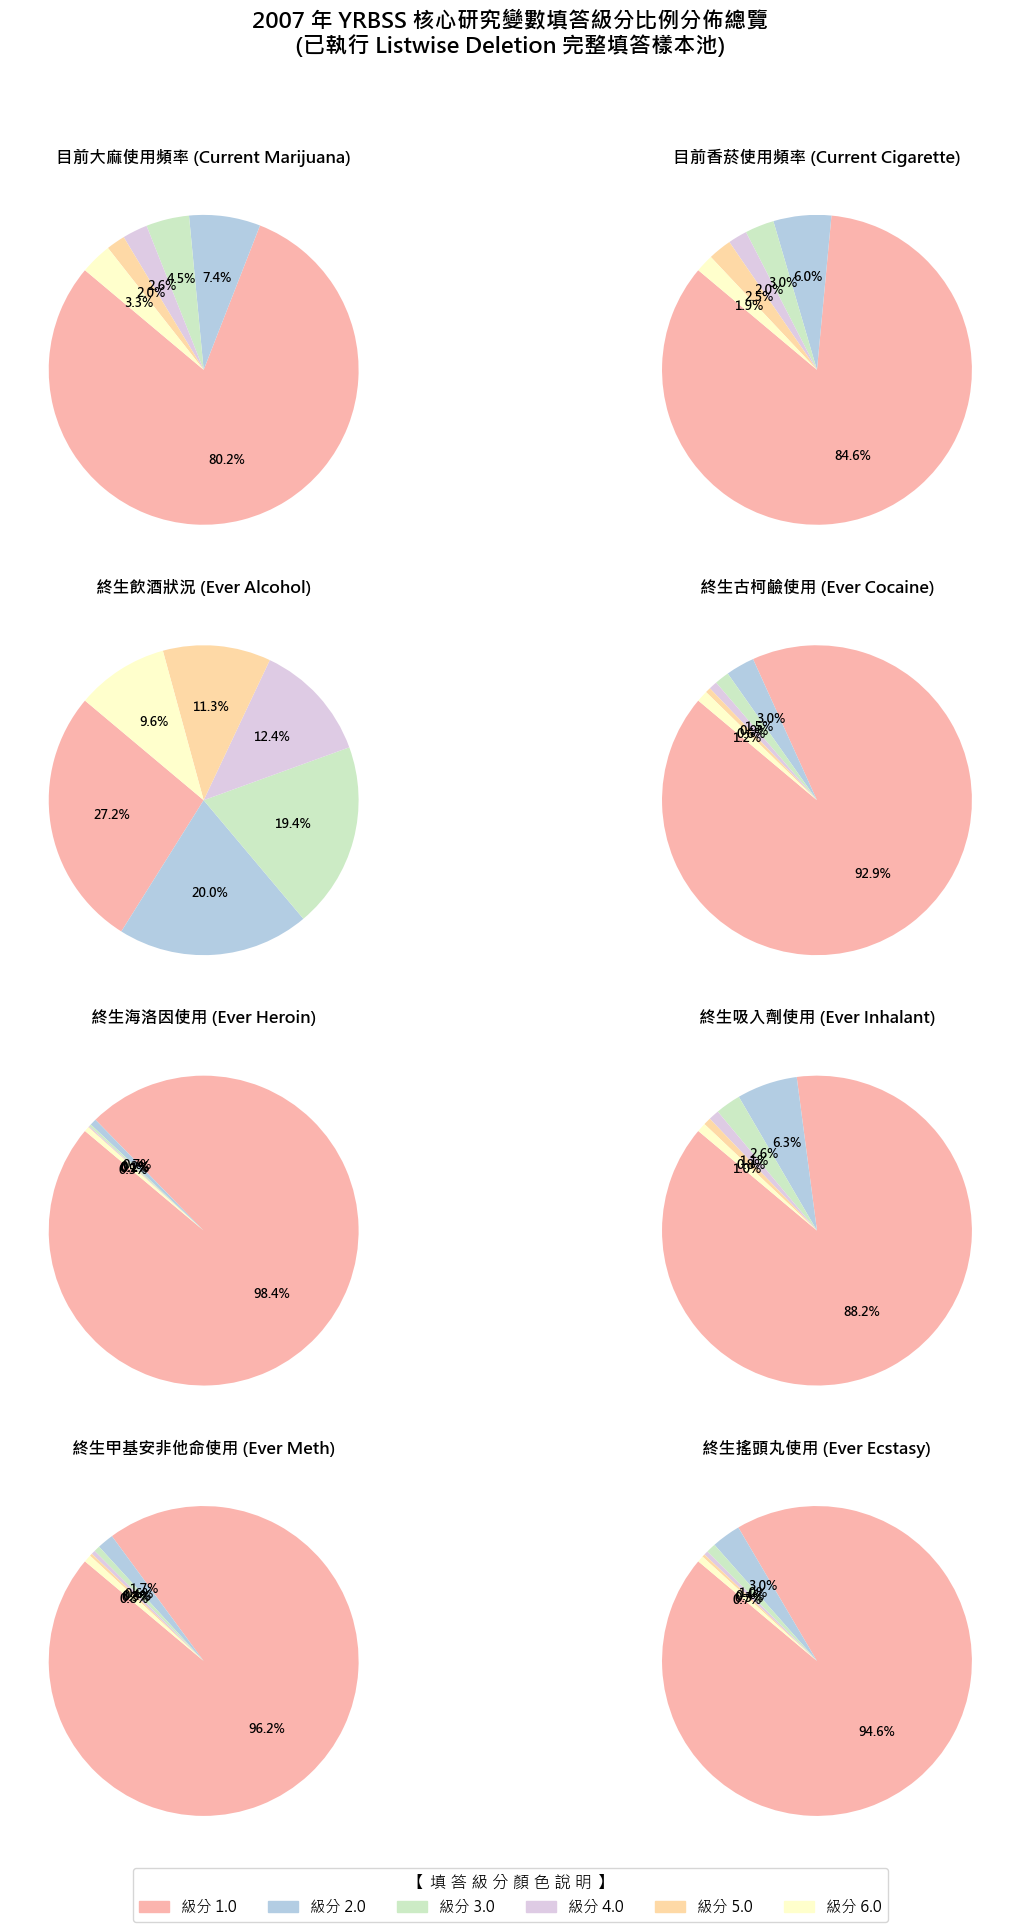

In [25]:
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # ✨ 修正：補上關鍵字 as！
import pandas as pd

# 🛠️ 環境防線：確保這一格能獨立完美執行（忽略警告與解鎖中文）
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 讀取剛才清洗乾淨的黃金資料集
processed_data_path = '../data/processed/02_core_variables_processed.csv'
df_processed = pd.read_csv(processed_data_path)

# 2. 定義 8 個核心變數與其中文對照標題
target_columns = [
    'CurrentMarijuaUse', 'CurrentCigaretteUse', 'EverAlcoholUse',
    'EverCocaineUse', 'EverHeroinUse', 'EverInhalantUse',
    'EverMethamphetamineUse', 'EverEcstasyUse'
]

col_chinese_titles = {
    'CurrentMarijuaUse': '目前大麻使用頻率 (Current Marijuana)',
    'CurrentCigaretteUse': '目前香菸使用頻率 (Current Cigarette)',
    'EverAlcoholUse': '終生飲酒狀況 (Ever Alcohol)',
    'EverCocaineUse': '終生古柯鹼使用 (Ever Cocaine)',
    'EverHeroinUse': '終生海洛因使用 (Ever Heroin)',
    'EverInhalantUse': '終生吸入劑使用 (Ever Inhalant)',
    'EverMethamphetamineUse': '終生甲基安非他命使用 (Ever Meth)',
    'EverEcstasyUse': '終生搖頭丸使用 (Ever Ecstasy)'
}

# 3. 強制鎖定 1.0 ~ 6.0 級分的絕對顏色映射（確保 8 顆圓餅圖顏色完全對稱）
all_scores = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
color_palette = plt.cm.Pastel1(range(6))
score_color_map = dict(zip(all_scores, color_palette))

# 4. 配置 4 列 2 行的網格畫布
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

print("📊 正在將 8 大核心變數的級分比例繪製為極簡風圓餅圖...")

# 5. 迴圈發動：依序繪製各變數圖表
for i, col in enumerate(target_columns):
    # 統計該變數 1.0 ~ 6.0 的數量，若某級分沒人選則自動補 0
    counts = df_processed[col].value_counts().reindex(all_scores, fill_value=0)
    
    # 剔除計數為 0 的級分（避免圓餅圖畫出無意義的 0% 空白切片）
    active_counts = counts[counts > 0]
    active_colors = [score_color_map[score] for score in active_counts.index]
    
    # 繪製單一圓餅圖
    wedges, texts, autotexts = axes[i].pie(
        active_counts, 
        labels=None,          # 拔除圓餅圖旁邊的文字標註
        autopct='%1.1f%%',    # 僅在餅圖內部顯示百分比
        startangle=140,
        colors=active_colors, # 套用鎖定的學術柔和配色
        textprops={'fontsize': 10}
    )
    
    # 加粗圓餅圖內的百分比數字
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_weight('bold')
        
    axes[i].set_title(col_chinese_titles[col], fontsize=12, fontweight='bold', pad=10)

# 6. 建立橫向排列的全域「統一圖例」
legend_patches = [mpatches.Patch(color=score_color_map[score], label=f'級分 {score}') for score in all_scores]
fig.legend(
    handles=legend_patches, 
    loc='lower center', 
    ncol=6,                   # 讓 6 個級分橫向並排一列
    title="【 填 答 級 分 顏 色 說 明 】", 
    title_fontsize=12,
    fontsize=11, 
    bbox_to_anchor=(0.5, 0.01) # 精準擺放在全圖最底端
)

# 7. 設定全域大標題與排版優化
plt.suptitle('2007 年 YRBSS 核心研究變數填答級分比例分佈總覽\n(已執行 Listwise Deletion 完整填答樣本池)', 
             fontsize=16, fontweight='bold', y=0.97)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

# 8. 安全存入指定輸出目錄 (編號對齊第二階段 02)
output_fig_path = '../outputs/figures/02_variables_pie_distribution.png'
os.makedirs(os.path.dirname(output_fig_path), exist_ok=True)
plt.savefig(output_fig_path, dpi=300)

print(f"🎉 視覺化大功告成！8 顆極簡圓餅圖（含底端橫向全域圖例）已成功存檔至: {output_fig_path}")
plt.show()